### Q1. What is the relationship between polynomial functions and kernel functions in machine learning algorithms?

In machine learning, particularly in the context of support vector machines (SVM) and other kernel methods, polynomial functions and kernel functions are closely related but serve slightly different roles.
Polynomial Functions:
A polynomial function is a mathematical expression. These functions can be used to model relationships between data points where the decision boundary or relationship is not linear, but rather polynomial

Kernel Functions:
A kernel function is a method used to compute a similarity (or inner product) between two data points in a higher-dimensional feature space without explicitly computing their coordinates in that space. This is done using a trick called the kernel trick, which allows the algorithm to implicitly map the original data into a higher-dimensional space where linear separation may be easier

### Q2. How can we implement an SVM with a polynomial kernel in Python using Scikit-learn?

Accuracy:  1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



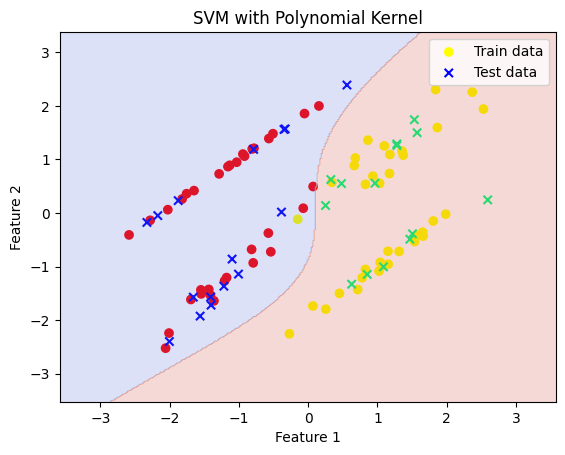

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Step 2: Load or generate a dataset (for example, the Iris dataset)
# Here, we use a simple 2D dataset for visualization purposes
X, y = datasets.make_classification(n_samples=100, n_features=2, n_redundant=0, n_classes=2, random_state=42)

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=999)

# Step 4: Create the SVM model with a polynomial kernel
svm_poly = SVC(kernel='poly', degree=3, C=1, coef0=1)  # degree=3 for a cubic polynomial kernel

# Step 5: Train the SVM model
svm_poly.fit(X_train, y_train)

# Step 6: Make predictions on the test set
y_pred = svm_poly.predict(X_test)

# Step 7: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optional: Visualize the decision boundary
# Plot the training data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='autumn', marker='o', label='Train data')

# Plot the test data
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='winter', marker='x', label='Test data')

# Create a mesh grid to plot the decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict class for each point in the mesh grid
Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM with Polynomial Kernel')
plt.legend()
plt.show()

### Q3. How does increasing the value of epsilon affect the number of support vectors in SVR?

In Support Vector Regression (SVR), the parameter epsilon (ε) plays a crucial role in determining the tolerance for errors when fitting the regression model. Increasing the value of epsilon has a direct impact on the number of support vectors. Let's explore how it works:
#### What is Epsilon (ε)?
In SVR, epsilon (ε) defines a tube around the true data points within which no penalty is applied for errors.
The model tries to fit the data within this epsilon tube (also called the epsilon-insensitive tube). Data points that fall inside this tube are not penalized by the model.
Data points that fall outside this tube are considered support vectors, and they contribute to the loss function, influencing the model.
Effect of Increasing Epsilon on Support Vectors:
##### Larger Epsilon (ε):
- When you increase the value of epsilon, the epsilon-insensitive tube becomes wider.
- This means that more data points will fall within the tube and will no longer be considered as support vectors.
- As a result, fewer support vectors are selected because more points are within the tube and don’t contribute to the model’s loss.
- The model will likely underfit the data, because it allows for more error (larger deviations from the true values) without penalizing those errors.
##### Smaller Epsilon (ε):
- When you decrease the value of epsilon, the epsilon-insensitive tube becomes narrower.
- Fewer data points will be considered as "insider" points, and more points will fall outside the tube.
- As a result, more support vectors will be selected, as these points will lie outside the tube and contribute to the model’s loss.
- The model is more sensitive to errors, and it will likely overfit the data because it tries to fit the training data points more precisely.
##### Practical Considerations:
- When selecting epsilon, it’s important to balance the trade-off between underfitting and overfitting. If the epsilon value is too large, the model becomes overly simplistic (underfitting), and if it's too small, the model may become overly complex and fit noise (overfitting).

### Q4. How does the choice of kernel function, C parameter, epsilon parameter, and gamma parameter affect the performance of Support Vector Regression (SVR)? Can you explain how each parameter works and provide examples of when you might want to increase or decrease its value?

In Support Vector Regression (SVR), several parameters play an essential role in determining the model's performance. These parameters include the kernel function, C parameter, epsilon (ε) parameter, and gamma parameter. Understanding how each of these parameters affects the model can help you tune your SVR to perform well on different types of data.

Let’s break down each parameter, how it works, and how changes in its value can affect the performance of SVR:

#### 1. Kernel Function:
The kernel function defines the transformation of the input data into a higher-dimensional space, which makes it possible to model non-linear relationships.

- Common kernel types:
  - Linear Kernel: The simplest kernel that doesn't transform the data; it’s used when the data is linearly separable.
  - Polynomial Kernel: Uses polynomial functions to transform the data. It allows capturing polynomial relationships between data points.
  - Radial Basis Function (RBF) Kernel: Uses the Gaussian function to map the data to an infinite-dimensional space, making it useful for complex, non-linear relationships.
  - Sigmoid Kernel: Less commonly used, based on the hyperbolic tangent function.
- Effect of Kernel Function:
  - Linear Kernel: Used when the data is linearly separable or nearly linear. It’s faster and more interpretable but limited in its ability to model complex, non-linear relationships.
  - Polynomial Kernel: Suitable for data where the relationship between features is polynomial in nature. Larger degrees of the polynomial can fit more complex data but might lead to overfitting.
  - RBF Kernel: The most popular kernel for non-linear regression tasks. It works well for most data and is particularly good when the decision boundary is complex and non-linear.
  - Sigmoid Kernel: Rarely used, as it can lead to issues such as overfitting and instability.
#### 2. C Parameter (Regularization Parameter):
The C parameter controls the trade-off between bias and variance. It’s a regularization parameter that determines how much the model should penalize errors.

- Large C: A large value of C makes the model more sensitive to errors (lower bias). The model tries to fit the training data as closely as possible, even if it leads to overfitting. It reduces the margin (tolerance to error) in favor of minimizing the number of misclassified points, which can increase model complexity.

- Small C: A smaller value of C allows for a larger margin and more tolerance to errors, which results in a simpler model (higher bias but lower variance). The model focuses on finding a balance between fitting the data and keeping the model simple, which can prevent overfitting but might underfit if set too small.

When to adjust C:
  - Increase C if the model underfits (i.e., the training error is high). This forces the model to fit the data more closely and reduces bias.
  - Decrease C if the model overfits (i.e., the model is too complex and has high variance). This helps to avoid overfitting by allowing more margin for error.
#### 3. Epsilon (ε) Parameter:
The epsilon (ε) parameter defines a tube around the true values where no penalty is applied for errors. It controls how much deviation from the true values is acceptable without penalty.

- Large ε: A larger epsilon creates a wider tube, allowing more data points to fall within the tube and not contribute to the loss. As a result, the model is more tolerant to errors, which can lead to underfitting. It might produce a smoother regression curve that doesn't capture small nuances in the data.

- Small ε: A smaller epsilon creates a narrower tube, meaning fewer points are ignored, and errors outside the tube are penalized. This forces the model to fit the data more closely, which can lead to overfitting, as the model will try to minimize errors as much as possible, even if they are small or caused by noise in the data.

When to adjust epsilon:
- Increase ε if you want to allow more error tolerance and have a simpler model with fewer support vectors. This can be helpful when you suspect noise in the data and want a smoother fit.
- Decrease ε if you need a more precise fit and want to capture smaller details in the data. However, this may lead to overfitting, especially if the data is noisy.
#### 4. Gamma Parameter (for RBF Kernel):
The gamma parameter defines the spread of the data points in the RBF kernel. It determines how far the influence of a single training point reaches.

- Large gamma: A high value of gamma means that the influence of each data point is localized, causing the model to fit very closely to the training data. This leads to low bias and high variance, which can cause overfitting. The decision boundary becomes very jagged, and the model may not generalize well to unseen data.

- Small gamma: A smaller value of gamma means that the influence of each data point is spread out, resulting in a smoother decision boundary. This can increase bias but reduce variance, making the model more general and less prone to overfitting. However, if gamma is too small, the model may be too simplistic and underfit the data.

When to adjust gamma:
- Increase gamma if the model underfits and you need a more complex model to capture the fine details in the data. This might be necessary for data with intricate, non-linear relationships.
- Decrease gamma if the model is overfitting. A smaller gamma will result in a smoother and more general decision boundary, which might improve performance on unseen data.

Parameter	High Value Effect	Low Value Effect
Kernel	RBF, polynomial for complex relationships	Linear for simpler, linear relationships
C	More complex model, lower bias, higher variance	Simpler model, higher bias, lower variance
Epsilon (ε)	Larger tube, more error tolerance, underfitting	Narrower tube, more precise fit, overfitting
Gamma	Overfitting, highly sensitive to data points	Underfitting, smoother, more general model
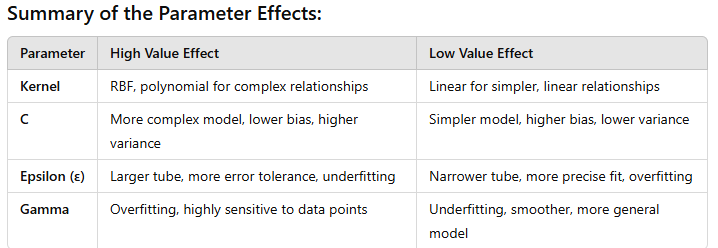

#### Practical Example:
- 1. When to Increase C: If your model is underfitting (i.e., the training error is high, and the model doesn't capture the data well), you may want to increase the C parameter. This forces the model to fit the data more closely and reduces bias.

- 2. When to Decrease C: If your model is overfitting (i.e., the training error is very low but the test error is high), you may want to decrease C. This will help the model generalize better by allowing more error tolerance in the model.

- 3. When to Increase Epsilon: If your data is noisy or contains outliers, you might increase epsilon to ignore small errors, allowing the model to be smoother and more robust to noise.

- 4. When to Decrease Epsilon: If you have clean data and want to capture finer details or more complex patterns, you might decrease epsilon to make the model more sensitive to errors.

- 5. When to Increase Gamma: If your data has complex, non-linear relationships, you may increase gamma to allow the model to capture these intricate patterns. However, be cautious as this can lead to overfitting if the value is too high.

- 6. When to Decrease Gamma: If the model is overfitting and capturing too many details, you may decrease gamma to make the model smoother and more general.

Q5. Assignment:
- Import the necessary libraries and load the dataseg
- Split the dataset into training and testing setZ
- Preprocess the data using any technique of your choice (e.g. scaling, normalizationK
- Create an instance of the SVC classifier and train it on the training datW
- Use the trained classifier to predict the labels of the testing datW
- Evaluate the performance of the classifier using any metric of your choice (e.g. accuracy,
precision, recall, F1-scoreK
- Tune the hyperparameters of the SVC classifier using GridSearchCV or RandomizedSearchCV to
improve its performanc_
- Train the tuned classifier on the entire dataseg
- Save the trained classifier to a file for future use.

In [10]:
# Step 1: Import the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import joblib

# Step 2: Load the dataset (using iris dataset as an example, replace with your dataset)
data = load_iris()  # Replace with your own dataset loading code
X = data.data
y = data.target

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Preprocess the data (Scaling the features using StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Create an instance of the SVC classifier and train it on the training data
svc = SVC(kernel='rbf', random_state=42)  # Using RBF kernel as an example
svc.fit(X_train_scaled, y_train)

# Step 6: Predict the labels of the testing data
y_pred = svc.predict(X_test_scaled)

# Step 7: Evaluate the performance of the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 8: Tune the hyperparameters using GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'gamma': [0.01, 0.1, 1],  # Kernel coefficient
    'kernel': ['rbf', 'linear']  # Type of kernel
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# Best parameters from grid search
print("Best parameters found: ", grid_search.best_params_)

# Step 9: Train the tuned classifier on the entire dataset
best_svc = grid_search.best_estimator_
best_svc.fit(X_train_scaled, y_train)

# Step 10: Save the trained classifier to a file for future use
joblib.dump(best_svc, 'trained_svc_model.pkl')
print("Model saved as 'trained_svc_model.pkl'")

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found:  {'C': 10, 'gamma': 0.01, 'kernel': 'linear'}
Model saved as 'trained_svc_model.pkl'
